In [1]:
# =====================================================
# IMPORTS
# =====================================================
import xarray as xr
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from shapely.geometry import Point
from shapely.prepared import prep
from cartopy.io.shapereader import Reader as ShapeReader
import dask
# =====================================================
# CONFIG
# =====================================================
xr.set_options(keep_attrs=True)

base_dir = "/home/lacrio/DATA/term_cal/res_new_700"
csv_days = "/home/lacrio/DATA/term_cal/range_date_evets.csv"
nc_pattern = "era5_t_uvw_{start}_{end}_thermo_budget.nc"

vars_plot = ["dT/dt", "adv_h", "adv_v", "Q"]
titles = ["dT/dt", "Horizontal Advection", "Vertical Advection", "Diabatic Heating"]


In [2]:
def load_event(row, i, rel_time_axis):

    start = pd.to_datetime(row["start_date"])
    end   = pd.to_datetime(row["end_date"])
    central = pd.to_datetime(row["event_date"]).replace(hour=12)

    path = os.path.join(
        base_dir,
        nc_pattern.format(
            start=start.strftime("%Y%m%d"),
            end=end.strftime("%Y%m%d")
        )
    )

    if not os.path.exists(path):
        print(f"⚠️ Missing: {path}")
        return None

    # --- Open dataset ---
    #ds = xr.open_dataset(path)[vars_plot].astype("float32")
    ds = xr.open_dataset(path, chunks="auto")

    time_coord = "valid_time" if "valid_time" in ds.coords else "time"

    # --- Build integer relative time (KEY FIX) ---
    time_vals = ds[time_coord].values
    rel_time = ((time_vals - np.datetime64(central)) / np.timedelta64(1, "h")).astype("int32")

    ds = ds.assign_coords({time_coord: rel_time})
    ds = ds.rename({time_coord: "time"})

    # --- Select window ---
    ds = ds.sel(time=slice(rel_time_axis.min(), rel_time_axis.max()))

    # --- Reindex to FORCE SAME TIME AXIS ---
    ds = ds.reindex(time=rel_time_axis)

    # --- Apply scaling AFTER alignment ---
    ds = ds * 3600

    # --- Add event dimension ---
    ds = ds.expand_dims(event=[i])

    return ds

In [3]:
df = pd.read_csv(csv_days)#[0:20]
rel_time_axis = np.arange(-96, 97, 1, dtype=np.int32)
df

,start_date,event_date,end_date
0,1980-02-12,1980-02-17,1980-02-22
1,1980-12-18,1980-12-23,1980-12-28
2,1981-01-21,1981-01-26,1981-01-31
3,1981-12-04,1981-12-09,1981-12-14
4,1982-02-25,1982-03-02,1982-03-07
...,...,...,...
95,2021-11-04,2021-11-09,2021-11-14
96,2021-12-03,2021-12-08,2021-12-13
97,2021-12-14,2021-12-19,2021-12-24
98,2022-02-02,2022-02-07,2022-02-12


In [4]:
datasets = []

for i, row in df.iterrows():

    ds_evt = load_event(row, i, rel_time_axis)

    if ds_evt is None:
        continue

    datasets.append(ds_evt)

    if i % 10 == 0:
        print(f"➡️ Added {i+1} events")

➡️ Added 1 events
➡️ Added 11 events
➡️ Added 21 events
➡️ Added 31 events
➡️ Added 41 events
➡️ Added 51 events
➡️ Added 61 events
➡️ Added 71 events
➡️ Added 81 events
➡️ Added 91 events


In [5]:
ds_comp = xr.concat(datasets, dim="event")

In [7]:
# =====================================================
# MASK FUNCTION (UNCHANGED LOGIC)
# =====================================================
def mask_with_shapefile(ds, shp_path):

    geoms = [geom.simplify(0.05)
             for geom in ShapeReader(shp_path).geometries()]
    geoms = [prep(geom) for geom in geoms]

    lon = ds.longitude.values
    lat = ds.latitude.values

    lon2d, lat2d = np.meshgrid(lon, lat)
    mask = np.zeros(lon2d.shape, dtype=bool)

    print("🔹 Creating shapefile mask...")

    for i in range(lat2d.shape[0]):
        for j in range(lat2d.shape[1]):
            pt = Point(lon2d[i, j], lat2d[i, j])
            inside = any(geom.contains(pt) for geom in geoms)
            mask[i, j] = not inside

    print("✅ Mask ready")
    return mask


# =====================================================
# LOAD DATA (assumed already loaded as ds_comp)
# =====================================================
# ds_comp = ...

# =====================================================
# COMMON WEIGHTS (cos(lat))
# =====================================================
weights = np.cos(np.deg2rad(ds_comp.latitude))


# =====================================================
# PATAGONIA ICEFIELD (SHAPEFILE MASK + WEIGHTS)
# =====================================================
shp_path = "/home/lacrio/Patagonia-Antarctic_Peninsula/data/shp/Glaciers_NPI_SPI.shp"

mask_PI = mask_with_shapefile(ds_comp, shp_path)

mask_PI_da = xr.DataArray(
    mask_PI,
    coords={"latitude": ds_comp.latitude, "longitude": ds_comp.longitude},
    dims=("latitude", "longitude")
)

# aplicar máscara a pesos
weights_PI = weights.where(~mask_PI_da).fillna(0)

# promedio ponderado
ds_PI = ds_comp.weighted(weights_PI).mean(
    dim=("latitude", "longitude", "event")
)

print("Patagonia Icefield weighted mean:")
print(ds_PI)


# =====================================================
# ANTARCTIC PENINSULA (LAND MASK + WEIGHTS)
# =====================================================
land_feature = cfeature.NaturalEarthFeature("physical", "land", "10m")
land_geom = [prep(geom) for geom in land_feature.geometries()]

lon2d, lat2d = np.meshgrid(ds_comp.longitude.values,
                           ds_comp.latitude.values)

mask_AP = np.zeros(lon2d.shape, dtype=bool)

print("🔹 Creating AP mask...")

for i in range(lon2d.shape[0]):
    for j in range(lon2d.shape[1]):
        pt = Point(lon2d[i, j], lat2d[i, j])
        if not any(geom.contains(pt) for geom in land_geom):
            mask_AP[i, j] = True

# limitar región
mask_AP[(lat2d < -68) | (lat2d > -60)] = True

print("✅ AP mask ready")

mask_AP_da = xr.DataArray(
    mask_AP,
    coords={"latitude": ds_comp.latitude, "longitude": ds_comp.longitude},
    dims=("latitude", "longitude")
)

weights_AP = weights.where(~mask_AP_da).fillna(0)

ds_AP = ds_comp.weighted(weights_AP).mean(
    dim=("latitude", "longitude", "event")
)

print("Antarctic Peninsula weighted mean:")
print(ds_AP)

🔹 Creating shapefile mask...
✅ Mask ready
Patagonia Icefield weighted mean:
<xarray.Dataset> Size: 7kB
Dimensions:  (time: 193)
Coordinates:
  * time     (time) int32 772B -96 -95 -94 -93 -92 -91 -90 ... 91 92 93 94 95 96
Data variables:
    dT_dt    (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
    adv_h    (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
    adv_v    (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
    Q        (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
Attributes:
    description:  Thermodynamic budget at 700 hPa (NHESS method)
    history:      Computed from ERA5 single file
🔹 Creating AP mask...
✅ AP mask ready
Antarctic Peninsula weighted mean:
<xarray.Dataset> Size: 7kB
Dimensions:  (time: 193)
Coordinates:
  * time     (time) int32 772B -96 -95 -94 -93 -92 -91 -90 ... 91 92 93 94 95 96
Data variables:
    dT_dt    (time) float64 2kB dask.array<chunksize=(193,), meta=np.ndarray>
    adv_h  

In [8]:
ds_12UTC = ds_comp.sel(time = 0).mean('event')

In [9]:
# -----------------------------------------------------------------------------
# Plot configuration
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

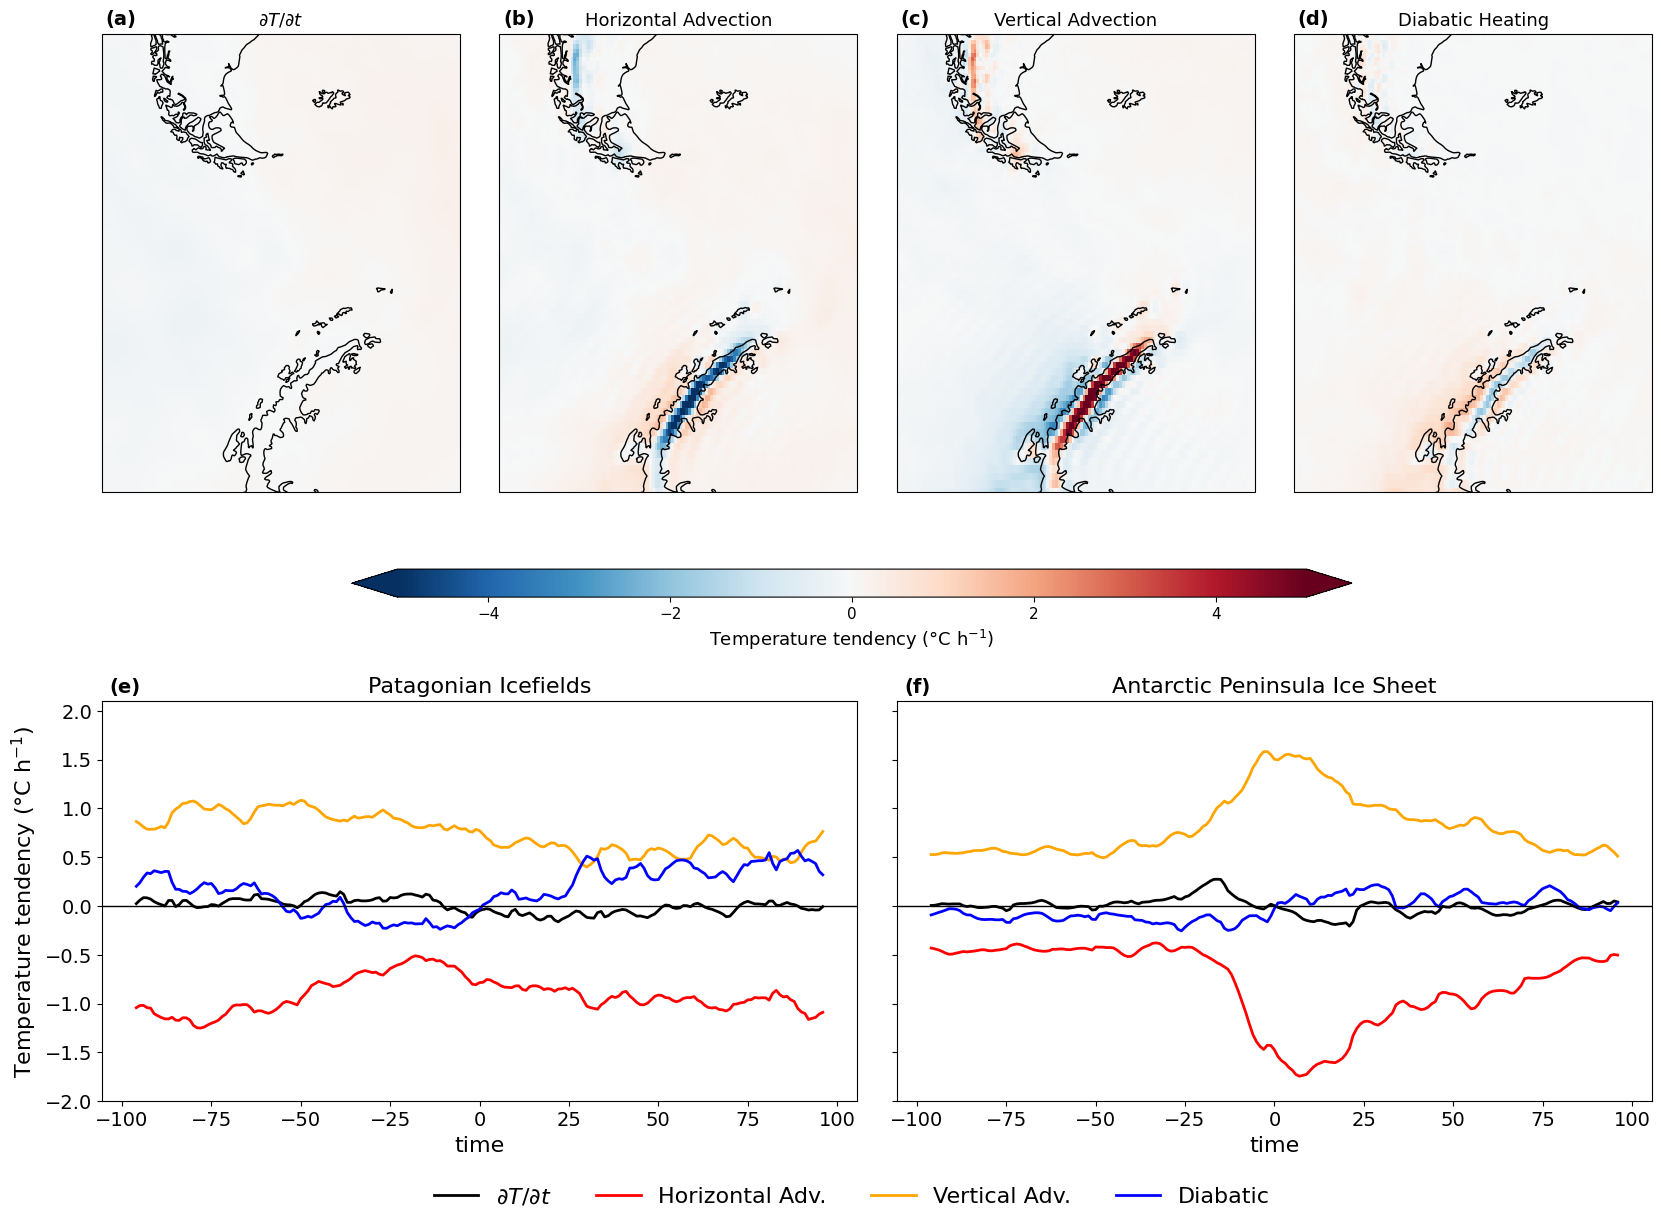

In [10]:
# =====================================================
# VARIABLES
# =====================================================
vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    r"$\partial T / \partial t$",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic Heating"
]

labels = {
    "dT_dt": r"$\partial T / \partial t$",
    "adv_h": "Horizontal Adv.",
    "adv_v": "Vertical Adv.",
    "Q": "Diabatic"
}

colors = {
    "dT_dt": "black",
    "adv_h": "red",
    "adv_v": "orange",
    "Q": "blue"
}

# =====================================================
# PLOTTING
# =====================================================
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

extent = [-80, -48, -68, -48]

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    2, 8,
    height_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.25
)

# =====================================================
# MAPS (4 panels)
# =====================================================
for i, v in enumerate(vars_plot):

    ax = fig.add_subplot(gs[0, 2*i:2*i+2], projection=proj_map)

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

    im = ax.pcolormesh(
        ds_12UTC.longitude,
        ds_12UTC.latitude,
        ds_12UTC[v],
        cmap="RdBu_r",
        vmin=-5, vmax=5,
        shading="auto",
        transform=proj_data
    )

    ax.set_extent(extent)
    ax.set_title(titles[i], fontsize=13)

    ax.text(
        0.01, 1.02, f"({chr(97+i)})",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14
    )

# =====================================================
# COLORBAR
# =====================================================
cax = fig.add_axes([0.25, 0.47, 0.5, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='both')
cbar.set_label("Temperature tendency (°C h$^{-1}$)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# =====================================================
# TIME SERIES
# =====================================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[1, 0:4])

for v in vars_plot:
    ds_PI[v].plot(
        ax=ax1,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax1.set_title("Patagonian Icefields", fontsize=16)
ax1.axhline(0, color="k", linewidth=1)

ax1.set_ylabel("Temperature tendency (°C h$^{-1}$)", fontsize=16)
ax1.set_ylim(-2.0, 2.1)
ax1.tick_params(labelsize=14)

ax1.text(0.01, 1.02, "(e)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold')


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[1, 4:8])

for v in vars_plot:
    ds_AP[v].plot(
        ax=ax2,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax2.set_title("Antarctic Peninsula Ice Sheet", fontsize=16)
ax2.axhline(0, color="k", linewidth=1)

ax2.set_ylabel("")
ax2.set_ylim(-2.0, 2.1)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=14)

ax2.text(0.01, 1.02, "(f)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold')


# =====================================================
# 🔥 SHARED LEGEND (BEST PRACTICE)
# =====================================================
handles, legend_labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 0.02)
)

# =====================================================
# SAVE
# =====================================================
os.makedirs("./fig", exist_ok=True)

fig.savefig(
    "./fig/temp_tendency_4vars.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
filename = "/home/lacrio/DATA/term_cal/res_new_700/era5_t_uvw_20200205_20200215_thermo_budget.nc"
ds = xr.open_dataset(filename) * 3600

ds_12UTC = ds.sel(valid_time = '20200207T12')

ds_AP = ds.where(mask_AP == False).mean(("latitude", "longitude"))
ds_PI = ds.where(mask_PI == False).mean(("latitude", "longitude"))


In [ ]:
df = ds_AP.to_dataframe() 
df['sum_terms'] = df[['adv_h', 'adv_v', 'Q']].sum(axis=1)
df

,dT_dt,adv_h,adv_v,Q,sum_terms
valid_time,,,,,
2020-02-05 00:00:00,0.172943,0.073313,0.371846,-0.272216,0.172943
2020-02-05 01:00:00,0.198465,0.078912,0.423313,-0.303760,0.198465
2020-02-05 02:00:00,0.242451,0.105016,0.453486,-0.316050,0.242451
2020-02-05 03:00:00,0.267487,0.115847,0.512080,-0.360440,0.267487
2020-02-05 04:00:00,0.273014,0.118356,0.506138,-0.351480,0.273014
...,...,...,...,...,...
2020-02-15 19:00:00,-0.121324,-0.082022,0.212642,-0.251944,-0.121324
2020-02-15 20:00:00,-0.142499,-0.091159,0.291686,-0.343026,-0.142499
2020-02-15 21:00:00,-0.216833,-0.126335,0.326918,-0.417416,-0.216833


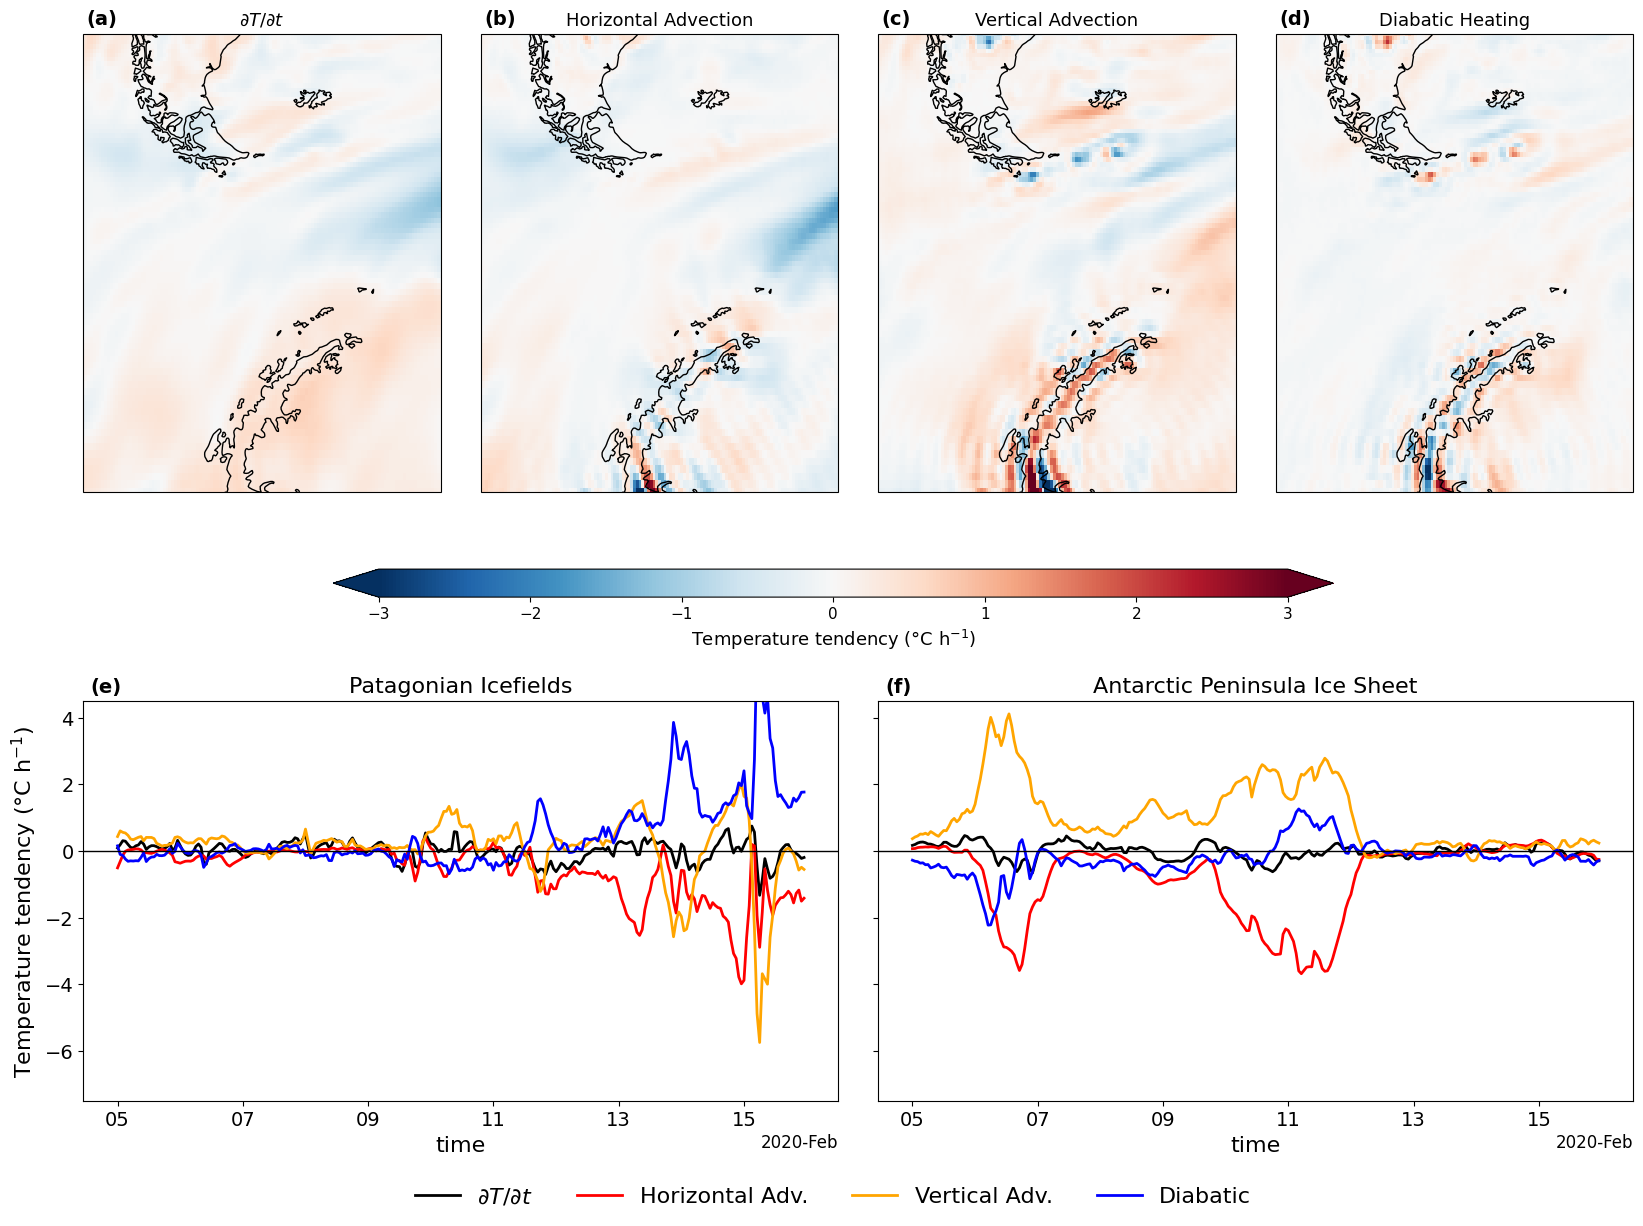

In [ ]:
# =====================================================
# VARIABLES
# =====================================================
vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    r"$\partial T / \partial t$",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic Heating"
]

labels = {
    "dT_dt": r"$\partial T / \partial t$",
    "adv_h": "Horizontal Adv.",
    "adv_v": "Vertical Adv.",
    "Q": "Diabatic"
}

colors = {
    "dT_dt": "black",
    "adv_h": "red",
    "adv_v": "orange",
    "Q": "blue"
}

# =====================================================
# PLOTTING
# =====================================================
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

extent = [-80, -48, -68, -48]

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    2, 8,
    height_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.25
)

# =====================================================
# MAPS (4 panels)
# =====================================================
for i, v in enumerate(vars_plot):

    ax = fig.add_subplot(gs[0, 2*i:2*i+2], projection=proj_map)

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

    im = ax.pcolormesh(
        ds_12UTC.longitude,
        ds_12UTC.latitude,
        ds_12UTC[v],
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        shading="auto",
        transform=proj_data
    )

    ax.set_extent(extent)
    ax.set_title(titles[i], fontsize=13)

    ax.text(
        0.01, 1.02, f"({chr(97+i)})",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14
    )

# =====================================================
# COLORBAR
# =====================================================
cax = fig.add_axes([0.25, 0.47, 0.5, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='both')
cbar.set_label("Temperature tendency (°C h$^{-1}$)", fontsize=13)
cbar.ax.tick_params(labelsize=11)


# =====================================================
# TIME SERIES
# =====================================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[1, 0:4])

for v in vars_plot:
    ds_PI[v].plot(
        ax=ax1,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax1.set_title("Patagonian Icefields", fontsize=16)
ax1.axhline(0, color="k", linewidth=1)

ax1.set_ylabel("Temperature tendency (°C h$^{-1}$)", fontsize=16)
ax1.set_ylim(-7.5, 4.5)
ax1.tick_params(labelsize=14)

ax1.text(0.01, 1.02, "(e)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold')


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[1, 4:8])

for v in vars_plot:
    ds_AP[v].plot(
        ax=ax2,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax2.set_title("Antarctic Peninsula Ice Sheet", fontsize=16)
ax2.axhline(0, color="k", linewidth=1)

ax2.set_ylabel("")
ax2.set_ylim(-7.5, 4.5)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=14)

ax2.text(0.01, 1.02, "(f)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold')


# =====================================================
# 🔥 SHARED LEGEND (BEST PRACTICE)
# =====================================================
handles, legend_labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 0.02)
)


In [ ]:
# =====================================================
# MASK FUNCTION (UNCHANGED)
# =====================================================
import numpy as np

ds_PI_sel = ds_comp.sel(
    longitude=slice(-75, -71),
    latitude=slice(-52, -45.8)
)

# pesos (solo latitud)
weights_PI = np.cos(np.deg2rad(ds_PI_sel.latitude))

ds_PI = ds_PI_sel.weighted(weights_PI).mean(
    dim=("latitude", "longitude", "event")
)

ds_AP_sel = ds_comp.sel(
    longitude=slice(-70, -60),
    latitude=slice(-70, -67)
)

weights_AP = np.cos(np.deg2rad(ds_AP_sel.latitude))

ds_AP = ds_AP_sel.weighted(weights_AP).mean(
    dim=("latitude", "longitude", "event")
)

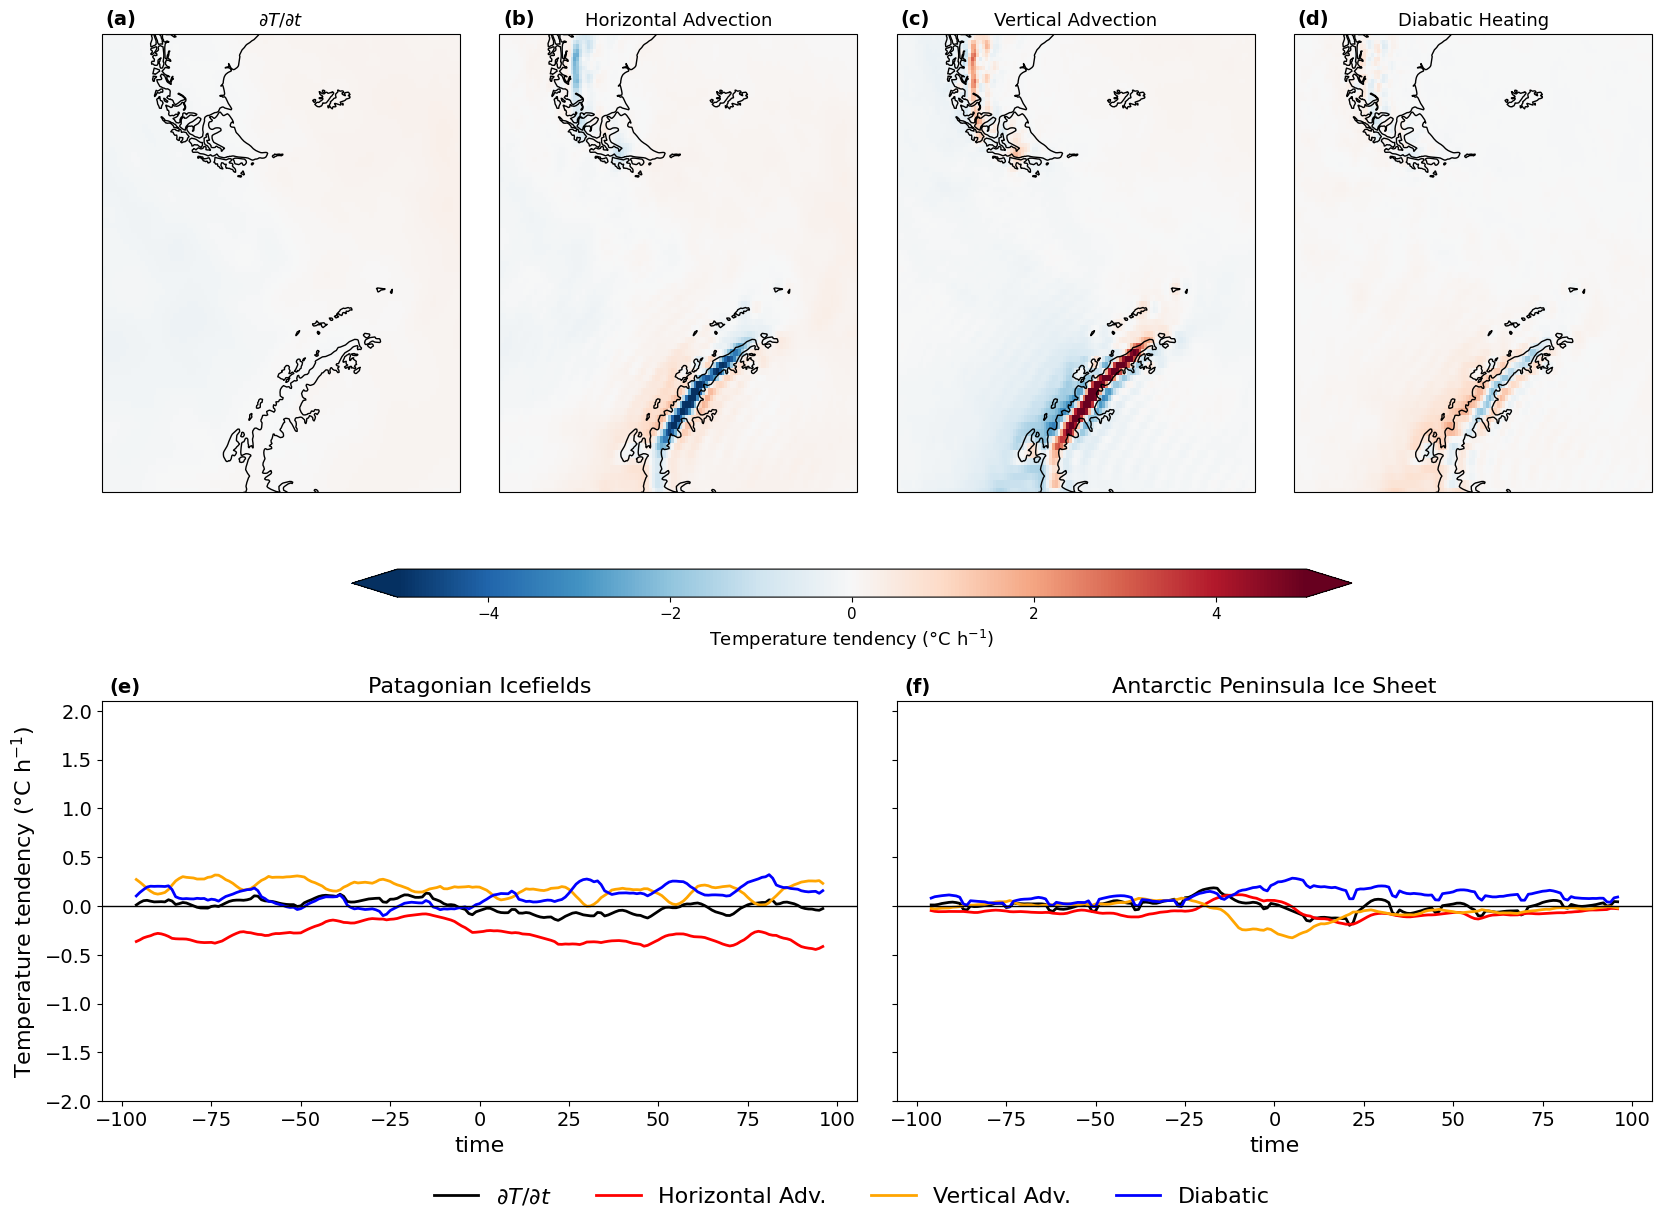

In [ ]:
ds_12UTC = ds_comp.sel(time = 0).mean('event')

# =====================================================
# VARIABLES
# =====================================================
vars_plot = ["dT_dt", "adv_h", "adv_v", "Q"]

titles = [
    r"$\partial T / \partial t$",
    "Horizontal Advection",
    "Vertical Advection",
    "Diabatic Heating"
]

labels = {
    "dT_dt": r"$\partial T / \partial t$",
    "adv_h": "Horizontal Adv.",
    "adv_v": "Vertical Adv.",
    "Q": "Diabatic"
}

colors = {
    "dT_dt": "black",
    "adv_h": "red",
    "adv_v": "orange",
    "Q": "blue"
}

# =====================================================
# PLOTTING
# =====================================================
proj_map = ccrs.Mercator()
proj_data = ccrs.PlateCarree()

extent = [-80, -48, -68, -48]

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    2, 8,
    height_ratios=[1.2, 1],
    hspace=0.45,
    wspace=0.25
)

# =====================================================
# MAPS (4 panels)
# =====================================================
for i, v in enumerate(vars_plot):

    ax = fig.add_subplot(gs[0, 2*i:2*i+2], projection=proj_map)

    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray")

    im = ax.pcolormesh(
        ds_12UTC.longitude,
        ds_12UTC.latitude,
        ds_12UTC[v],
        cmap="RdBu_r",
        vmin=-5, vmax=5,
        shading="auto",
        transform=proj_data
    )

    ax.set_extent(extent)
    ax.set_title(titles[i], fontsize=13)

    ax.text(
        0.01, 1.02, f"({chr(97+i)})",
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14
    )

# =====================================================
# COLORBAR
# =====================================================
cax = fig.add_axes([0.25, 0.47, 0.5, 0.02])

cbar = fig.colorbar(im, cax=cax, orientation="horizontal", extend='both')
cbar.set_label("Temperature tendency (°C h$^{-1}$)", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# =====================================================
# TIME SERIES
# =====================================================

# --- Patagonia ---
ax1 = fig.add_subplot(gs[1, 0:4])

for v in vars_plot:
    ds_PI[v].plot(
        ax=ax1,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax1.set_title("Patagonian Icefields", fontsize=16)
ax1.axhline(0, color="k", linewidth=1)

ax1.set_ylabel("Temperature tendency (°C h$^{-1}$)", fontsize=16)
ax1.set_ylim(-2.0, 2.1)
ax1.tick_params(labelsize=14)

ax1.text(0.01, 1.02, "(e)", transform=ax1.transAxes,
         fontsize=14, fontweight='bold')


# --- Antarctic Peninsula ---
ax2 = fig.add_subplot(gs[1, 4:8])

for v in vars_plot:
    ds_AP[v].plot(
        ax=ax2,
        label=labels[v],
        color=colors[v],
        linewidth=2
    )

ax2.set_title("Antarctic Peninsula Ice Sheet", fontsize=16)
ax2.axhline(0, color="k", linewidth=1)

ax2.set_ylabel("")
ax2.set_ylim(-2.0, 2.1)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=14)

ax2.text(0.01, 1.02, "(f)", transform=ax2.transAxes,
         fontsize=14, fontweight='bold')


# =====================================================
# 🔥 SHARED LEGEND (BEST PRACTICE)
# =====================================================
handles, legend_labels = ax1.get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=16,
    bbox_to_anchor=(0.5, 0.02)
)

# =====================================================
# SAVE
# =====================================================
os.makedirs("./fig", exist_ok=True)
'''
fig.savefig(
    "./fig/temp_tendency_4vars.png",
    dpi=300,
    bbox_inches="tight"
)
'''
plt.show()